# Market Data Analysis - Multi-Asset Exploratory Study

## Overview
This notebook performs data anaylsis on 2 years of daily OHLCV market data for SPY, QQQ and GLD, sourced from Alpaca API 
and stored in a local SQLite database

**Sections:**
1. Load data from SQLite
2. Descriptive statistics across all assets
3. Volume analysis - highest volume days and price correlation
4. Return distributions with normality tests
5. Summary report 

**Tools:** Python, panadas, SQLite, matplotlib, seaborn, scipy

In [3]:
#imports and datbase connection
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

#connect to existing database
conn = sqlite3.connect("market_data.db")

print("connected to database")
print(pd.read_sql("SELECT ticker, COUNT(*) as rows FROM price_bars GROUP BY ticker",conn))


connected to database
  ticker  rows
0    GLD   501
1    QQQ   501
2    SPY   501


In [4]:
#Load and clean data from SQLite
#Load all price bars from database
df = pd.read_sql("""
    SELECT ticker, date, open, high, low, close, volume
    FROM price_bars
    ORDER BY ticker, date
""", conn)

#clean types
df["date"] = pd.to_datetime(df["date"])
df["close"] = df["close"].astype(float)
df["volume"] = df["volume"].astype(float)
df["open"] = df["open"].astype(float)
df["high"] = df["high"].astype(float)
df["low"] = df["low"].astype(float)

#compute daily returns per ticker
df["return"] = df.groupby("ticker")["close"].pct_change()

#summary
print(f"Total rows: {len(df)}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Tickers : {df['ticker'].unique().tolist()}")
print()
print(df.groupby("ticker")["date"].count().rename("trading_days"))
    

Total rows: 1503
Date range: 2024-06-10 to 2026-06-09
Tickers : ['GLD', 'QQQ', 'SPY']

ticker
GLD    501
QQQ    501
SPY    501
Name: trading_days, dtype: int64


In [6]:
#Descriptive statistics across all assets
stats_table = df.groupby("ticker").agg(
    avg_close = ("close", "mean"),  # mean of close → column named avg_close
    std_close = ("close",  "std"),
    min_close = ("close",  "min"),
    max_close = ("close",  "max"),
    avg_daily_volume = ("volume", "mean"),
    avg_return = ("return", "mean"),
    std_return = ("return", "std"),
    skewness = ("return", lambda x: x.dropna().skew()), # measures asymmetry, 0 = symmetric
    kurtosis = ("return", lambda x: x.dropna().kurtosis()), #measures tail heaviness (extreme events), 0 = normal distr.
    trading_days = ("close",  "count")
).round(4)

#annualise return and volatility
stats_table["ann_return_pct"] = (stats_table["avg_return"] *252 *100).round(2) #Returns scale linearly
stats_table["ann_vol_pct"] = (stats_table["std_return"] * np.sqrt(252) * 100).round(2) #Volatility scales with square root

print("=== Descriptive Statistics - All Assets ===")
print(stats_table[[
    "avg_close", "min_close","max_close",
    "ann_return_pct","ann_vol_pct",
    "skewness","kurtosis","avg_daily_volume"
]].to_string())

print()
print("Kurtosis interpretation: ")
for ticker, row in stats_table.iterrows():
    k = row["kurtosis"]
    label = "heavy fat tails" if k>10 else "moderate fat tails" if k>1 else "near normal"
    print(f" {ticker}: {k:.2f} - {label}")

=== Descriptive Statistics - All Assets ===
        avg_close  min_close  max_close  ann_return_pct  ann_vol_pct  skewness  kurtosis  avg_daily_volume
ticker                                                                                                    
GLD      320.3109   212.5800     495.90           32.76        22.70   -0.9597    6.9813      7.561916e+06
QQQ      549.0391   414.0558     746.16           25.20        21.59    0.6400   12.9457      3.303316e+07
SPY      617.0644   490.8531     759.57           17.64        16.83    1.0502   21.7317      4.761120e+07

Kurtosis interpretation: 
 GLD: 6.98 - moderate fat tails
 QQQ: 12.95 - heavy fat tails
 SPY: 21.73 - heavy fat tails


**GLD (Gold)**
- Skewness -0.96 = crashes worse than rallies (crash hedge property)
- Kurtosis 6.98 = occasional extreme moves
- Safest tail behaviour (lowest kurtosis)
  
**QQQ(tech)**
- skewness +0.64 = upside bias (tech rallies)
- kurtosis 12.95 = frequent extrame swings (tech volatility)
- moderate tail risk

**SPY (broad market)**
- skewness +1.05 = highly right-skewed (rallies more likely than crashes historically)
- kurtosis 21.73 = extreme tail risk (highest kurtosis)
- most prone to sudden moves (crashes and rallies)


In [14]:
# volume analysis and price move correlation
# identify the highest volume days for each asset and measure whether volue predicts price moves:
#--volume analysis--
print("== Top 5 highest volume days per assets ==")
top_vol = (df.dropna(subset=["return"])#remove reuturn = null rows
            .sort_values("volume",ascending=False) #sort by volume(highest first)
            .groupby("ticker")
            .head(5)[["ticker","date","close","volume","return"]]
            .sort_values(["ticker","volume"], ascending=[True,False])) #sort by ticker, then volume
top_vol["return_pct"] = (top_vol["return"]*100).round(2)
top_vol["volume_M"] = (top_vol["volume"]/1e6).round(1)

print(top_vol[["ticker","date","close","volume_M","return_pct"]]
      .rename(columns={"volume_M":"volume(M)","return_pct":"return(%)"})
              .to_string(index=False)) # hide the index column

#--volume vs return correlation ----
print("--volume vs absolute return correlation--")
df["abs_return"] = df["return"].abs() #measure price volatility without direction
df["log_volume"] = np.log(df["volume"]) # normalize trading activity across different scales

corr_results = {}
for ticker, group in df.dropna().groupby("ticker"):
    corr, pval = stats.pearsonr(group["log_volume"], group["abs_return"]) #Calculate Pearson correlation
    corr_results[ticker] = {"correlation": round(corr,3),"p_value": round(pval,4)} #Saves correlation + p-value for each ticker
    

corr_df = pd.DataFrame(corr_results).T # transpose (swap rows/columns)
print(corr_df)
print()
print("Interpretation: positive correlation = higher volume days tend to")
print("have larger price moves (in either direction) — classic market microstructure.")

== Top 5 highest volume days per assets ==
ticker       date      close  volume(M)  return(%)
   GLD 2026-01-30 444.950012       86.6     -10.27
   GLD 2026-01-29 495.899994       70.0       0.27
   GLD 2026-01-28 494.559998       44.2       3.88
   GLD 2026-02-02 427.130005       41.6      -4.00
   GLD 2026-01-21 443.600006       38.8       1.46
   QQQ 2025-04-07 421.649078      161.6       0.24
   QQQ 2025-04-09 463.755249      142.9      12.00
   QQQ 2025-04-04 420.633972      117.1      -6.21
   QQQ 2025-04-10 444.030670      108.4      -4.25
   QQQ 2025-04-08 414.055786      101.2      -1.80
   SPY 2025-04-07 498.663544      256.6      -0.18
   SPY 2025-04-09 542.402222      241.9      10.50
   SPY 2025-04-04 499.553345      218.0      -5.85
   SPY 2025-04-08 490.853119      165.8      -1.57
   SPY 2026-03-20 648.570007      163.6      -1.43
--volume vs absolute return correlation--
     correlation  p_value
GLD        0.283      0.0
QQQ        0.223      0.0
SPY        0.215     

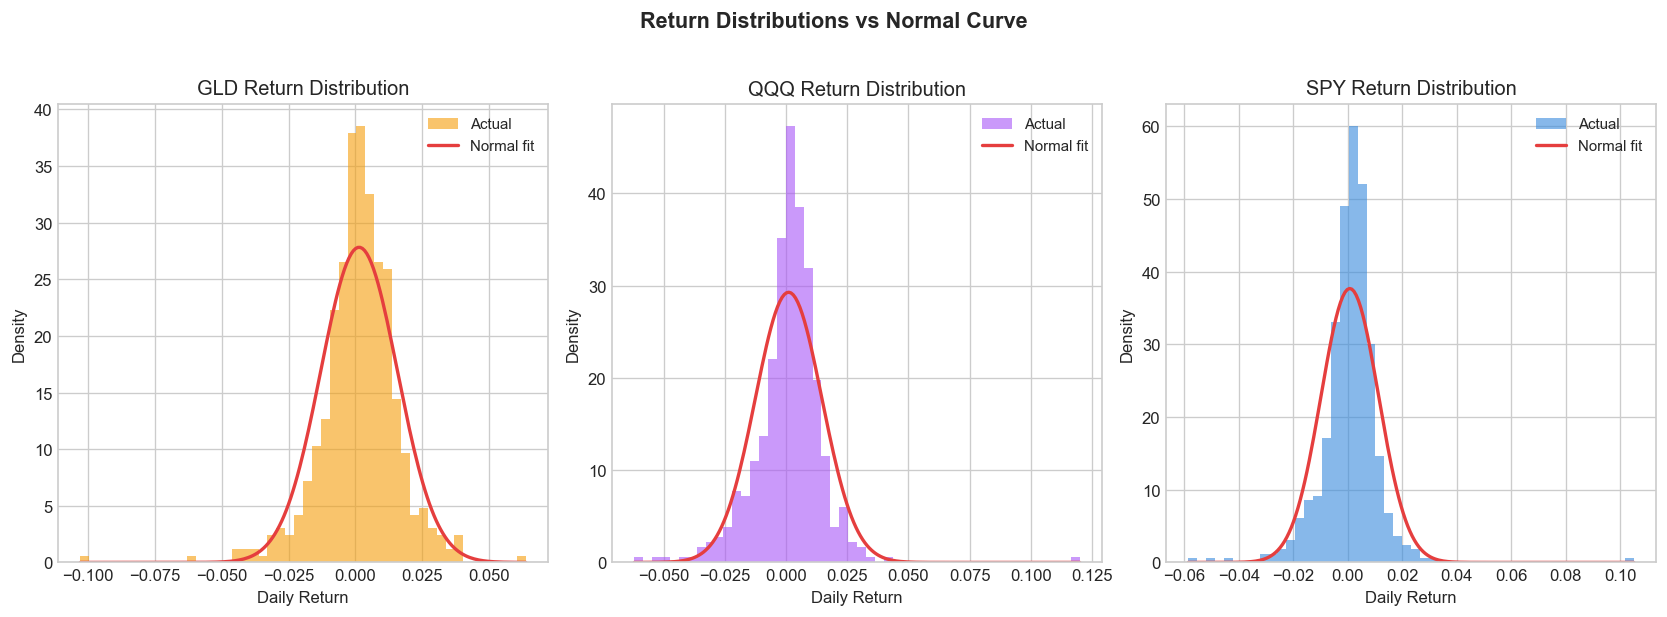

=== Shapiro-Wilk Normality Test ===
(p < 0.05 means returns are NOT normally distributed)

GLD: stat=0.9341, p=0.0000 → NOT normal | kurtosis=6.98
QQQ: stat=0.8953, p=0.0000 → NOT normal | kurtosis=12.95
SPY: stat=0.8420, p=0.0000 → NOT normal | kurtosis=21.73


In [15]:
#Return distribution plots with normality tests
# ── RETURN DISTRIBUTION PLOTS ───────────────────────────
tickers = df["ticker"].unique()
fig, axes = plt.subplots(1, len(tickers), figsize=(14, 5))
colors = {"SPY":"#378ADD","QQQ":"#A855F7","GLD":"#F59E0B"}

for i, ticker in enumerate(tickers):
    returns = df[df["ticker"]==ticker]["return"].dropna()
    ax = axes[i]

    # Histogram of actual returns
    ax.hist(returns, bins=50, density=True, alpha=0.6,
            color=colors.get(ticker,"#888"), label="Actual")

    # Fitted normal distribution overlay
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color="#E53E3E", linewidth=2, label="Normal fit")

    ax.set_title(f"{ticker} Return Distribution")
    ax.set_xlabel("Daily Return")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Return Distributions vs Normal Curve", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── NORMALITY TESTS ──────────────────────────────────────
print("=== Shapiro-Wilk Normality Test ===")
print("(p < 0.05 means returns are NOT normally distributed)")
print()
for ticker in tickers:
    returns = df[df["ticker"]==ticker]["return"].dropna()
    # Use sample for Shapiro (max 5000 obs)
    sample  = returns.sample(min(500, len(returns)), random_state=42)
    stat, p = stats.shapiro(sample)
    result  = "NOT normal" if p < 0.05 else "Normal"
    kurt    = returns.kurtosis()
    print(f"{ticker}: stat={stat:.4f}, p={p:.4f} → {result} | kurtosis={kurt:.2f}")

In [18]:
# ── SUMMARY REPORT ──────────────────────────────────────
summary = pd.DataFrame()

for ticker in df["ticker"].unique():
    t = df[df["ticker"]==ticker].copy()
    returns = t["return"].dropna()

    row = {
        "Ticker":            ticker,
        "Trading Days":      len(returns),
        "Date From":         t["date"].min().date(),
        "Date To":           t["date"].max().date(),
        "Avg Close ($)":     round(t["close"].mean(), 2),
        "Min Close ($)":     round(t["close"].min(), 2),
        "Max Close ($)":     round(t["close"].max(), 2),
        "Ann. Return (%)":   round(returns.mean()*252*100, 2),
        "Ann. Volatility (%)": round(returns.std()*np.sqrt(252)*100, 2),
        "Sharpe (approx)":   round((returns.mean()*252-0.045) /
                                    (returns.std()*np.sqrt(252)), 2),
        "Max Drawdown (%)":  round(
                                ((1+returns).cumprod() /
                                 (1+returns).cumprod().cummax()-1).min()*100, 2),
        "Skewness":          round(returns.skew(), 3),
        "Kurtosis":          round(returns.kurtosis(), 3),
        "Avg Daily Volume":  round(t["volume"].mean()),
        "Vol-Return Corr":   round(
                        stats.pearsonr(
                            np.log(t[["volume","abs_return"]].dropna()["volume"]),
                            t[["volume","abs_return"]].dropna()["abs_return"]
                        )[0], 3) if "abs_return" in t.columns
                     else "N/A"
    }
    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)

# Print to notebook
print("=== Final Summary Report ===")
print(summary.set_index("Ticker").to_string())

# Export to CSV
summary.to_csv("market_data_summary.csv", index=False)
print("Report exported: market_data_summary.csv")

conn.close()
print("Database connection closed.")

=== Final Summary Report ===
        Trading Days   Date From     Date To  Avg Close ($)  Min Close ($)  Max Close ($)  Ann. Return (%)  Ann. Volatility (%)  Sharpe (approx)  Max Drawdown (%)  Skewness  Kurtosis  Avg Daily Volume  Vol-Return Corr
Ticker                                                                                                                                                                                                                   
GLD              499  2024-06-10  2026-06-09         320.31         212.58         495.90            33.98                22.75             1.30            -20.10     -0.96     6.981           7561916            0.283
QQQ              499  2024-06-10  2026-06-09         549.04         414.06         746.16            24.71                21.63             0.93            -22.77      0.64    12.946          33033160            0.223
SPY              499  2024-06-10  2026-06-09         617.06         490.85         759.57          

## Key Finding — Return Distributions

All three assets reject normality under Shapiro-Wilk (p ≈ 0.000),
with kurtosis significantly above zero:

- SPY: kurtosis = 21.73 — extreme fat tails despite being the most
  diversified asset. Driven by episodic large moves during 2022 bear
  market that appear as extreme outliers relative to SPY's low baseline
  daily volatility.

- QQQ: kurtosis = 12.95 — heavy fat tails consistent with tech sector
  concentration and sensitivity to rate moves.

- GLD: kurtosis = 6.98 — lightest tails of the three but still
  significantly non-normal, reflecting macro-driven episodic spikes.

Implication: any risk model assuming normality — including the basic
Sharpe ratio used in the strategy notebook — underestimates the true
probability of extreme loss days. A 3-sigma move that a normal model
predicts happens once every 370 days may actually occur every few weeks
in practice.